In [1]:
import common_functions

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dust_time_trends = pd.read_csv("DATA/processed/6_time_trend_2026-05-07.csv")

In [3]:
dust_time_trends["moisture_norm"] = (
    dust_time_trends["moisture"]
    - dust_time_trends.groupby("dust_event_id")["moisture"].transform("first")
)
dust_time_trends

,index,date,latitude,longitude,start_time_utc,time_str,datetime,dust_event_id,moisture,moisture_norm
0,0,20010113,33.89,-102.94,1800,1800,2000-12-14 18:00:00,0,NaN,NaN
1,3492,20010113,33.89,-102.94,1800,1800,2000-12-15 18:00:00,0,NaN,NaN
2,6984,20010113,33.89,-102.94,1800,1800,2000-12-16 18:00:00,0,NaN,NaN
3,10476,20010113,33.89,-102.94,1800,1800,2000-12-17 18:00:00,0,NaN,NaN
4,13968,20010113,33.89,-102.94,1800,1800,2000-12-18 18:00:00,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
213007,199043,20201229,29.45,-106.33,1830,1830,2021-01-24 18:30:00,3491,NaN,NaN
213008,202535,20201229,29.45,-106.33,1830,1830,2021-01-25 18:30:00,3491,NaN,NaN
213009,206027,20201229,29.45,-106.33,1830,1830,2021-01-26 18:30:00,3491,NaN,NaN
213010,209519,20201229,29.45,-106.33,1830,1830,2021-01-27 18:30:00,3491,NaN,NaN


In [7]:
location_name = "San Luis Valley"
lat_min, lat_max, lon_min, lon_max = common_functions._get_coords_for_region(location_name)

dust_time_trends_filtered = dust_time_trends[
    (dust_time_trends["latitude"] >= lat_min) &
    (dust_time_trends["latitude"] <= lat_max) &
    (dust_time_trends["longitude"] >= lon_min) &
    (dust_time_trends["longitude"] <= lon_max)
]

print(f"{location_name} has {dust_time_trends_filtered["dust_event_id"].nunique()} of the {dust_time_trends["dust_event_id"].nunique()} events.")

San Luis Valley has 55 of the 3492 events.


In [8]:
rows = []
for id in dust_time_trends_filtered["dust_event_id"].unique():
    trend = dust_time_trends_filtered[dust_time_trends_filtered['dust_event_id']==id]['moisture_norm']
    rows.append(trend)
trend_2d = np.stack(rows)
trend_mean = np.nanmean(trend_2d, axis=0)
trend_std = np.nanstd(trend_2d, axis=0)

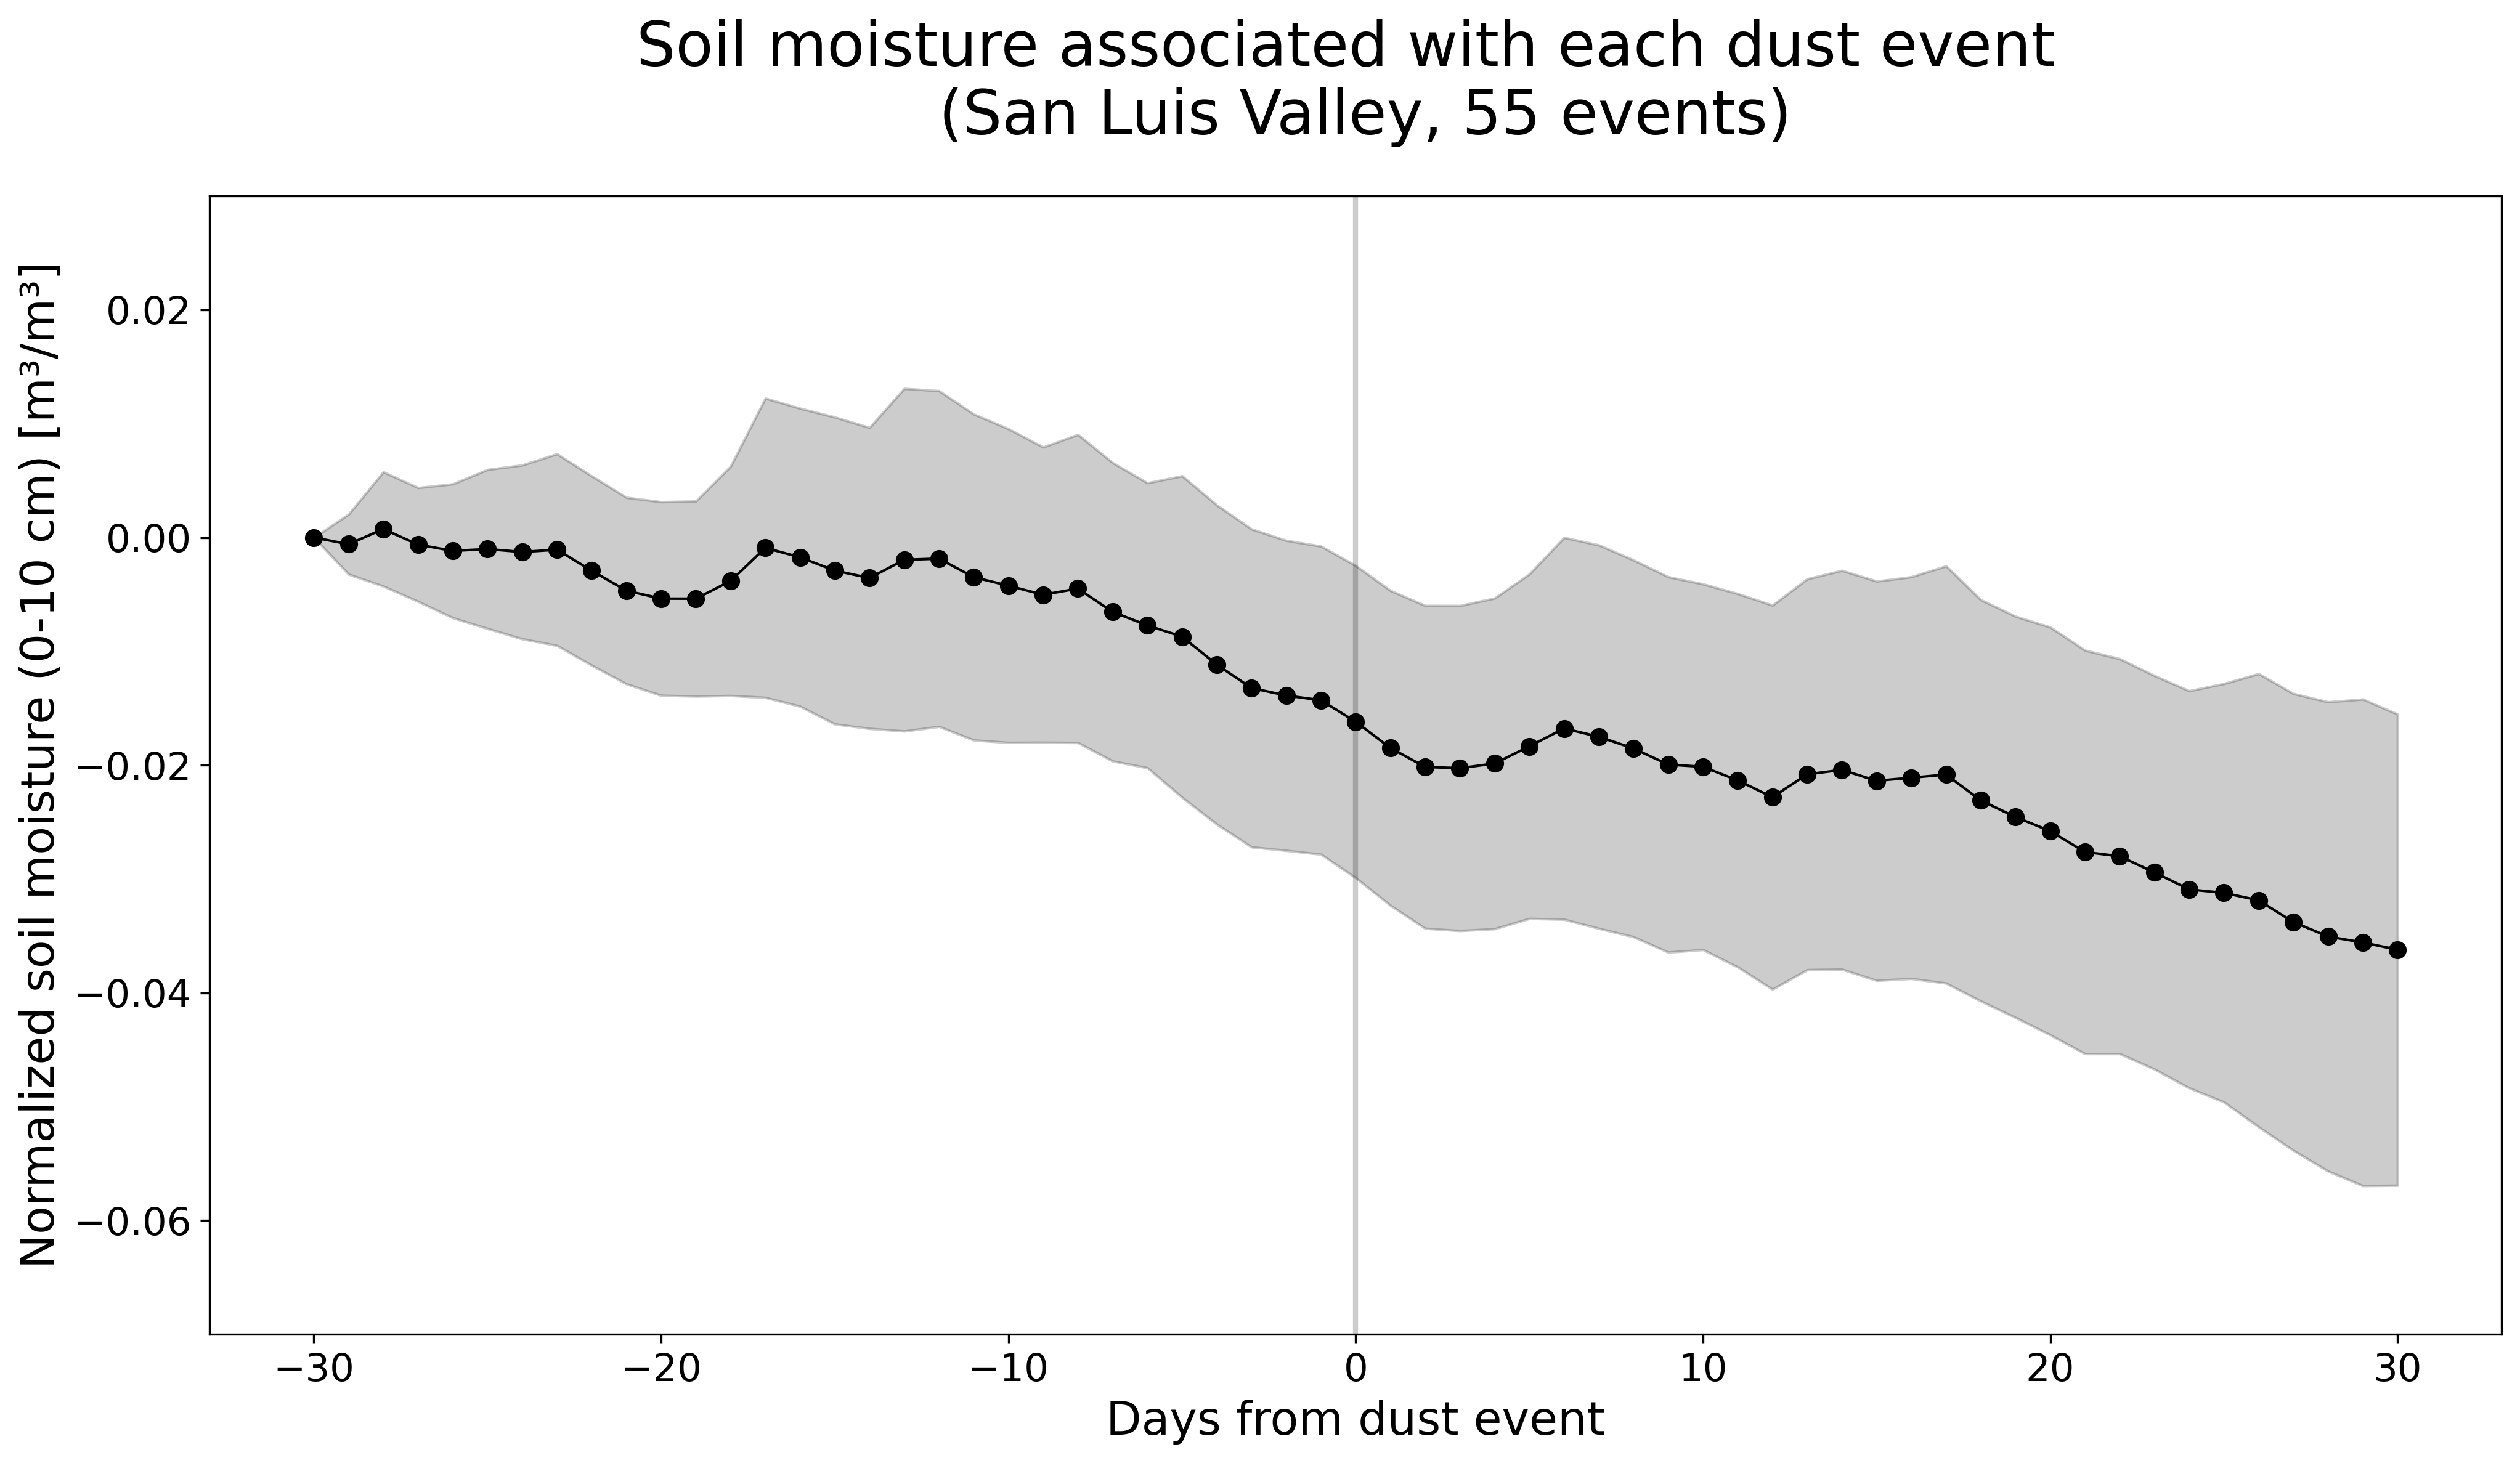

In [9]:
fig, ax = plt.subplots(figsize=(16, 8), dpi=300)

x = range(-30,31)

ax.plot(x, trend_mean, color='black', linewidth=1, marker='o')

ax.fill_between(x,
    trend_mean - trend_std/2,
    trend_mean + trend_std/2,
    color='black', alpha=0.2)

ax.axvline(x=0, color='black', linewidth=2, alpha=0.2)

ax.tick_params(axis='both', labelsize=15)
ax.set_ylabel("Normalized soil moisture (0-10 cm) [m³/m³]", fontsize=18)
ax.set_xlabel("Days from dust event", fontsize=18)
ax.set_title(f"Soil moisture associated with each dust event \n ({location_name}, {dust_time_trends_filtered["dust_event_id"].nunique()} events)", fontsize=24, pad=24)
ax.set_ylim(-0.07, 0.03)

plt.savefig(f"plots/2_soil_moisture_1_average_trend_{location_name.replace(" ", "_").lower()}.png",
            dpi=600, bbox_inches='tight')
plt.show()